# Task 3 — CycleGAN Image Style Transfer: Monet ↔ Photo
**Member:** Tejas · **Seed:** 1446 · DATA266 Lab 1

**Domains (same as the TA script):** **A = Monet** (`monet_jpg`, ~300), **B = Photo** (`photo_jpg`, ~7K).
`G_AB`: Monet→Photo writes to `outputs/pred_A2B/`. `G_BA`: Photo→Monet writes to `outputs/pred_B2A/`.

| Section | Brief item |
|---|---|
| 1 | 3.1 Two unpaired domains |
| 2 | 3.1 Two ResNet generators + two 70×70 PatchGAN discriminators |
| 3 | 3.1 Adversarial (LSGAN) + cycle-consistency + identity loss; stability logging |
| 4 | 3.1 Translation in both directions |
| 5 | 3.2 Cycle-consistency verification (reconstruction grids + L1) |
| 6 | 3.2 Kaggle `submission.csv` (TA-identical FID/MiFID) + full metrics via `../evaluate_local.py` |
| 7 | 3.2 Blinded human audit: 30 fixed samples, 2 raters, Cohen's kappa |
| 8 | All metrics, grouped → `full_metrics_report.csv` / `metrics_report.csv` |
| 9 | Export zip + verify, back up, and flush to Google Drive |

**Integrity:** submitted numbers come only from this model's inference. Pretrained Inception and LPIPS networks are used **only** in evaluation.
**Resuming:** rerunning the notebook resumes from `checkpoints/last.pt` (each session keeps its own untouched raw log; plots stitch them together). Delete `checkpoints/` to start a fresh run with a new config.
**Checkpoints:** `G_AB.pt` and `G_BA.pt` are weights-only generators (~46 MB each, committable). `last.pt` also holds both discriminators and optimizer state (~340 MB) for resuming, so keep it on Drive only.

> **How to read this notebook.** Everything is implemented. Items marked **🔷 DECISION** are choices you should confirm or change (and keep different from your teammate's), then justify in `results.md`. Run top to bottom; `SMOKE=1` runs a tiny end-to-end version.

## Colab setup (skip on HPC / local)
Colab starts in `/content`, so the notebook can't find its folder. Uncomment and edit the cell below **before** running anything else. The paths cell stops with a clear error if the working directory is wrong. Outputs then go straight to Drive, so they survive a disconnect, and training resumes from `checkpoints/last.pt`.

The data must be in `task3_gan/data/monet_jpg/` and `task3_gan/data/photo_jpg/` (from the Kaggle competition).

In [1]:
# ── Colab only: mount Drive and move into this notebook's src/ folder. Skip on HPC / local Jupyter. ──
# Replace <repo> with your repo folder on Drive. Clear this cell's path before committing.
# from google.colab import drive; drive.mount('/content/drive')
# %cd /content/drive/MyDrive/<repo>/task3_gan/tejas/src

In [2]:
# One-time setup (uncomment on a fresh machine / Colab). Versions are recorded in the manifest.
#%pip -q install -r ../../../requirements.txt

## 0. Config
### 🔷 DECISIONS
| Decision | Current value | Alternatives | Notes |
|---|---|---|---|
| Generator | ResNet, 9 residual blocks, ngf=64 (~11.4M params each) | ResNet-6 (faster) / U-Net | Paper default at 256px |
| Discriminator | 70×70 PatchGAN, ndf=64 | deeper or spectral norm | |
| GAN loss | LSGAN (MSE) | BCE / hinge | LSGAN is more stable |
| λ_cycle / λ_identity | 10 / 5 | 10 / 0, 5 / 2.5 | Identity keeps photo colors faithful |
| Optimizer | Adam 2e-4, β=(0.5, 0.999) | | |
| Schedule | constant for 100 epochs, then linear to 0 by 200 (paper) | 50 (25+25) for slower GPUs | |
| Epoch | 300 iterations (one pass over the Monet set; photos sampled randomly) | | |
| Image pool | 50 | none | Stabilizes D |
| Augmentation | resize 286 → random crop 256 + h-flip | | Essential with 300 Monets |
| Batch | 1 | 2–4 | InstanceNorm works with batch 1 |

**Time check:** iterations = `epochs × 300` = 60,000 at 200 epochs. At ~34 ms/iteration (RTX 4090) that is ~35–40 min; on a T4 it would be several hours, so use 50 epochs there.

In [3]:
# ── Paths & run mode (no personal paths: everything is relative or env-driven) ──
import os, sys
from pathlib import Path

SMOKE  = os.environ.get("SMOKE", "0") == "1"   # README smoke test: SMOKE=1 jupyter nbconvert --execute ...
MEMBER = "tejas"
SEED   = 1446                                  # last 4 digits of student ID

# Notebook lives in <task>/<member>/src/  ->  member dir is the parent of cwd.
# Fail fast if launched from the wrong folder (e.g. Colab starts in /content) so nothing is written to the wrong place.
if "MEMBER_DIR" not in os.environ and Path.cwd().name != "src":
    raise RuntimeError(
        f"Working directory is {Path.cwd()} — expected <repo>/<task>/<member>/src.\n"
        "Colab: run the 'Colab setup' cell above (mount Drive + %cd into src/) first. "
        "Elsewhere: cd into the src/ folder, or set the MEMBER_DIR environment variable.")
MEMBER_DIR = Path(os.environ.get("MEMBER_DIR", Path.cwd().parent)).resolve()
TASK_DIR   = MEMBER_DIR.parent
REPO_ROOT  = TASK_DIR.parent
DATA_DIR   = Path(os.environ.get("DATA_DIR", TASK_DIR / "data")).resolve()

CKPT_DIR   = MEMBER_DIR / "checkpoints"
OUT_DIR    = MEMBER_DIR / "outputs"
PROC_DIR   = MEMBER_DIR / "data_processed"
LOG_DIR    = REPO_ROOT / "reproducibility" / "raw_logs" / TASK_DIR.name / MEMBER
MANI_DIR   = REPO_ROOT / "reproducibility" / "manifests" / TASK_DIR.name / MEMBER
assert TASK_DIR.name.startswith("task"), f"Unexpected layout: TASK_DIR={TASK_DIR}"
for d in (CKPT_DIR, OUT_DIR, PROC_DIR, LOG_DIR, MANI_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"SMOKE={SMOKE}  MEMBER_DIR={MEMBER_DIR}\nDATA_DIR={DATA_DIR}")

SMOKE=False  MEMBER_DIR=<REPO>\task3_gan\tejas
DATA_DIR=<REPO>\task3_gan\data


In [4]:
CFG = dict(
    run_name="t3_cyclegan_" + MEMBER,
    img_size=256, load_size=286,
    n_res_blocks=9, ngf=64,          # 🔷
    ndf=64, n_d_layers=3,            # 🔷
    lambda_cycle=10.0, lambda_id=5.0,# 🔷
    lr=2e-4, betas=(0.5, 0.999),
    lr_D=7.5e-5,                          # 🔷 discriminators learn slower than generators (e200: D loss fell to ~0.06, D overpowering G) 
    epochs=300, decay_start_epoch=135,  # 🔷 270K it (900 x 300); 45% constant LR / 55% decay (i180k still improving at 180K)
    lambda_id_B2A_end=1.5,              # 🔷 Photo->Monet identity (G_BA term) ramps 5 -> 1.5 over the decay phase; Monet->Photo stays 5
    upsample="resize",
    diffaug="color,translation,cutout", # 🔷 DiffAugment on every discriminator input (limited-data fix: only 300 Monets)
    ema_decay=0.999,                    # 🔷 EMA of generator weights, used for snapshots / inference / submission
    snapshot_every_epochs=10,
    ckpt_every_epochs=5,             # resume granularity; G_*.pt / last.pt are also always saved at the final epoch
    iters_per_epoch=900,             # 🔷
    batch_size=1, pool_size=50,
    num_workers=0 if sys.platform in ("darwin", "win32") else 2,   # macOS/Windows can't pickle notebook-defined datasets into workers
    log_every=50, sample_every_epochs=5,
    n_eval=300,                      # TA script uses the first 300 sorted files per folder
    translate_all_photos=False,      # 🔷 True = translate all ~7K photos (slower; only 300 are scored)
    n_audit=30,
)
if SMOKE:
    CFG.update(img_size=64, load_size=72, n_res_blocks=2, ngf=16, ndf=16, epochs=2, decay_start_epoch=1,
               iters_per_epoch=8, log_every=2, ckpt_every_epochs=1, sample_every_epochs=1, n_eval=12, n_audit=6, num_workers=0)
CFG

{'run_name': 't3_cyclegan_tejas',
 'img_size': 256,
 'load_size': 286,
 'n_res_blocks': 9,
 'ngf': 64,
 'ndf': 64,
 'n_d_layers': 3,
 'lambda_cycle': 10.0,
 'lambda_id': 5.0,
 'lr': 0.0002,
 'betas': (0.5, 0.999),
 'lr_D': 7.5e-05,
 'epochs': 300,
 'decay_start_epoch': 135,
 'lambda_id_B2A_end': 1.5,
 'upsample': 'resize',
 'diffaug': 'color,translation,cutout',
 'ema_decay': 0.999,
 'snapshot_every_epochs': 10,
 'ckpt_every_epochs': 5,
 'iters_per_epoch': 900,
 'batch_size': 1,
 'pool_size': 50,
 'num_workers': 0,
 'log_every': 50,
 'sample_every_epochs': 5,
 'n_eval': 300,
 'translate_all_photos': False,
 'n_audit': 30}

In [5]:
# ── Plumbing utilities (implemented — not model logic) ──
import sys, json, time, math, random, platform, subprocess
import numpy as np
import torch

def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

def get_device() -> torch.device:
    if torch.cuda.is_available():         return torch.device("cuda")
    if torch.backends.mps.is_available(): return torch.device("mps")
    return torch.device("cpu")

def cpu_model() -> str:
    """Exact CPU model name (the brief asks for the exact CPU/GPU)."""
    try:
        if sys.platform == "win32":
            import winreg
            k = winreg.OpenKey(winreg.HKEY_LOCAL_MACHINE, r"HARDWARE\DESCRIPTION\System\CentralProcessor\0")
            return winreg.QueryValueEx(k, "ProcessorNameString")[0].strip()
        if sys.platform == "darwin":
            return subprocess.run(["sysctl", "-n", "machdep.cpu.brand_string"], capture_output=True, text=True).stdout.strip()
        with open("/proc/cpuinfo") as f:
            for line in f:
                if line.startswith("model name"):
                    return line.split(":", 1)[1].strip()
    except Exception:
        pass
    return platform.processor() or platform.machine()

def hardware_info(device) -> dict:
    info = {"platform": platform.platform(), "python": platform.python_version(),
            "torch": torch.__version__, "device": str(device),
            "cpu": cpu_model(), "cpu_count": os.cpu_count()}
    if device.type == "cuda":
        p = torch.cuda.get_device_properties(0)
        info.update(gpu=p.name, gpu_mem_gb=round(p.total_memory / 1e9, 2), cuda=torch.version.cuda)
    elif device.type == "mps":
        info.update(gpu="Apple Silicon GPU (MPS)")
    return info

class PeakMemory:
    """CUDA: true peak. MPS/CPU: sample() periodically and keep the max seen."""
    def __init__(self, device):
        self.device, self.max_mb = device, 0.0
        if device.type == "cuda":
            torch.cuda.reset_peak_memory_stats()
    def sample(self) -> float:
        if self.device.type == "cuda":
            cur = torch.cuda.max_memory_allocated() / 2**20
        elif self.device.type == "mps":
            cur = torch.mps.driver_allocated_memory() / 2**20
        else:
            try:
                import resource                      # Unix only
                r = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
                cur = r / 2**20 if sys.platform == "darwin" else r / 2**10
            except ImportError:
                cur = float("nan")
        self.max_mb = max(self.max_mb, cur)
        return self.max_mb

class RunLogger:
    """Append-only JSONL raw log. Evidence trail — never edit after the run."""
    def __init__(self, run_name: str):
        self.path = LOG_DIR / f"{run_name}_{time.strftime('%Y%m%d-%H%M%S')}.jsonl"
        self.f = open(self.path, "a", buffering=1)
        print("Raw log ->", self.path)
    def log(self, **kw):
        kw["wall_time"] = time.time()
        self.f.write(json.dumps(kw, default=float) + "\n")
    def close(self):
        self.f.close()

def read_log(path) -> list:
    with open(path) as f:
        return [json.loads(line) for line in f]

def save_checkpoint(path, **state):
    """Atomic save so a disconnect mid-write can't corrupt the checkpoint."""
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(".tmp"); torch.save(state, tmp); os.replace(tmp, path)

def load_checkpoint(path, device):
    path = Path(path)
    return torch.load(path, map_location=device, weights_only=False) if path.exists() else None

def count_params(model) -> int:
    return sum(p.numel() for p in model.parameters())

def write_manifest(cfg: dict, device, extra: dict = None):
    freeze = subprocess.run([sys.executable, "-m", "pip", "freeze"], capture_output=True, text=True).stdout
    (MANI_DIR / "requirements_frozen.txt").write_text(freeze)
    manifest = {"run_name": cfg["run_name"], "seed": SEED, "smoke": SMOKE, "config": cfg,
                "hardware": hardware_info(device), "created": time.strftime("%Y-%m-%d %H:%M:%S"),
                **(extra or {})}
    p = MANI_DIR / f"manifest_{cfg['run_name']}.json"
    p.write_text(json.dumps(manifest, indent=2, default=str))
    print("Manifest ->", p)

def write_metrics_csv(rows: list, path):
    import pandas as pd
    pd.DataFrame(rows).to_csv(path, index=False)
    print("Metrics ->", path)

set_seed(SEED)
DEVICE = get_device()
print(json.dumps(hardware_info(DEVICE), indent=2))

{
  "platform": "Windows-11-10.0.26200-SP0",
  "python": "3.12.10",
  "torch": "2.14.1+cu126",
  "device": "cuda",
  "cpu": "AMD Ryzen 9 7950X 16-Core Processor",
  "cpu_count": 32,
  "gpu": "NVIDIA GeForce RTX 4090",
  "gpu_mem_gb": 25.76,
  "cuda": "12.6"
}


## 1. Unpaired data (3.1.1)

Monet (A): 300   Photo (B): 7038
Unpaired: each step pairs Monet[i % 300] with a random photo -> 900 iterations/epoch, 270,000 total


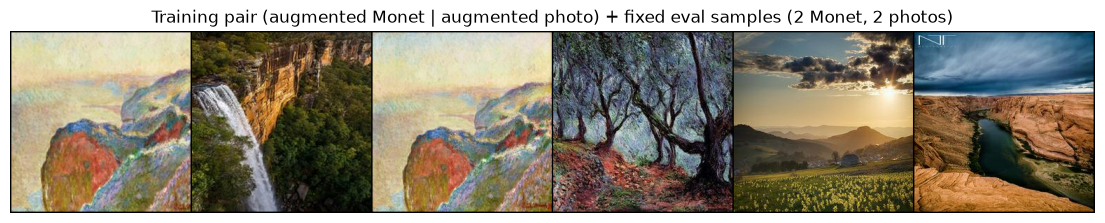

In [6]:
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as T
from torchvision.utils import save_image, make_grid
from torch.utils.data import Dataset, DataLoader
sys.path.insert(0, str(MEMBER_DIR))
import evaluate_local as EL

MONET_DIR, PHOTO_DIR = EL.find_domain_dir(DATA_DIR, "monet"), EL.find_domain_dir(DATA_DIR, "photo")
PRED_A2B, PRED_B2A, SAMPLE_DIR = OUT_DIR / "pred_A2B", OUT_DIR / "pred_B2A", OUT_DIR / "samples"
for d in (PRED_A2B, PRED_B2A, SAMPLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

def build_transforms(load_size, img_size, train):
    if train:
        return T.Compose([T.Resize(load_size, interpolation=T.InterpolationMode.BICUBIC), T.RandomCrop(img_size),
                          T.RandomHorizontalFlip(), T.ToTensor(), T.Normalize((0.5,) * 3, (0.5,) * 3)])
    return T.Compose([T.Resize(img_size, interpolation=T.InterpolationMode.BICUBIC), T.CenterCrop(img_size),
                      T.ToTensor(), T.Normalize((0.5,) * 3, (0.5,) * 3)])

class UnpairedDataset(Dataset):
    """A (Monet) cycles in order; B (Photo) is drawn independently at random -> unpaired."""
    def __init__(self, a_paths, b_paths, tf, length, seed):
        self.a, self.b, self.tf, self.length = a_paths, b_paths, tf, length
        self.epoch_seed = seed      # set per epoch; per-index RNG keeps workers independent and runs reproducible
    def __len__(self):
        return self.length
    def __getitem__(self, i):
        a = Image.open(self.a[i % len(self.a)]).convert("RGB")
        b = Image.open(self.b[int(np.random.default_rng([self.epoch_seed, i]).integers(len(self.b)))]).convert("RGB")
        return {"A": self.tf(a), "B": self.tf(b)}

def denorm(x):
    return (x.clamp(-1, 1) + 1) / 2

A_PATHS, B_PATHS = EL.list_images(MONET_DIR), EL.list_images(PHOTO_DIR)
print(f"Monet (A): {len(A_PATHS)}   Photo (B): {len(B_PATHS)}")
train_ds = UnpairedDataset(A_PATHS, B_PATHS, build_transforms(CFG["load_size"], CFG["img_size"], True),
                           CFG["iters_per_epoch"] * CFG["batch_size"], SEED)
EVAL_TF = build_transforms(CFG["load_size"], CFG["img_size"], False)
FIXED_A = torch.stack([EVAL_TF(Image.open(p).convert("RGB")) for p in A_PATHS[:4]])   # fixed visual-progress samples
FIXED_B = torch.stack([EVAL_TF(Image.open(p).convert("RGB")) for p in B_PATHS[:4]])
print(f"Unpaired: each step pairs Monet[i % {len(A_PATHS)}] with a random photo -> {CFG['iters_per_epoch']} iterations/epoch, "
      f"{CFG['epochs'] * CFG['iters_per_epoch']:,} total")
_s = train_ds[0]
save_image(make_grid(denorm(torch.stack([_s["A"], _s["B"], *FIXED_A[:2], *FIXED_B[:2]])), nrow=6), OUT_DIR / "data_examples.png")
plt.figure(figsize=(14, 3)); plt.imshow(Image.open(OUT_DIR / "data_examples.png")); plt.axis("off")
plt.title("Training pair (augmented Monet | augmented photo) + fixed eval samples (2 Monet, 2 photos)"); plt.show()

## 2. Generators and discriminators (3.1.2)

In [7]:
import itertools, collections
import torch.nn as nn

class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1), nn.Conv2d(ch, ch, 3), nn.InstanceNorm2d(ch), nn.ReLU(True),
            nn.ReflectionPad2d(1), nn.Conv2d(ch, ch, 3), nn.InstanceNorm2d(ch))
    def forward(self, x):
        return x + self.block(x)

class ResnetGenerator(nn.Module):
    """c7s1-64, d128, d256, R256 x n_res, u128, u64, c7s1-3 (Zhu et al. 2017)."""
    def __init__(self, ngf=64, n_res=9):
        super().__init__()
        layers = [nn.ReflectionPad2d(3), nn.Conv2d(3, ngf, 7), nn.InstanceNorm2d(ngf), nn.ReLU(True)]
        ch = ngf
        for _ in range(2):
            layers += [nn.Conv2d(ch, ch * 2, 3, stride=2, padding=1), nn.InstanceNorm2d(ch * 2), nn.ReLU(True)]; ch *= 2
        layers += [ResBlock(ch) for _ in range(n_res)]
        for _ in range(2):
            if CFG.get("upsample", "deconv") == "resize":     # resize-convolution: no checkerboard artifacts
                layers += [nn.Upsample(scale_factor=2, mode="nearest"), nn.ReflectionPad2d(1),
                           nn.Conv2d(ch, ch // 2, 3), nn.InstanceNorm2d(ch // 2), nn.ReLU(True)]
            else:                                            # original paper: transposed convolution
                layers += [nn.ConvTranspose2d(ch, ch // 2, 3, stride=2, padding=1, output_padding=1),
                           nn.InstanceNorm2d(ch // 2), nn.ReLU(True)]
            ch //= 2
        layers += [nn.ReflectionPad2d(3), nn.Conv2d(ch, 3, 7), nn.Tanh()]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

class PatchDiscriminator(nn.Module):
    """70x70 PatchGAN: C64-C128-C256-C512 -> 1-channel score map (no sigmoid, LSGAN)."""
    def __init__(self, ndf=64, n_layers=3):
        super().__init__()
        layers = [nn.Conv2d(3, ndf, 4, 2, 1), nn.LeakyReLU(0.2, True)]
        mult = 1
        for n in range(1, n_layers + 1):
            prev, mult = mult, min(2 ** n, 8)
            stride = 2 if n < n_layers else 1
            layers += [nn.Conv2d(ndf * prev, ndf * mult, 4, stride, 1), nn.InstanceNorm2d(ndf * mult), nn.LeakyReLU(0.2, True)]
        layers += [nn.Conv2d(ndf * mult, 1, 4, 1, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight, 0.0, 0.02)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

set_seed(SEED)
G_AB = ResnetGenerator(CFG["ngf"], CFG["n_res_blocks"]).to(DEVICE)   # Monet -> Photo
G_BA = ResnetGenerator(CFG["ngf"], CFG["n_res_blocks"]).to(DEVICE)   # Photo -> Monet
D_A  = PatchDiscriminator(CFG["ndf"], CFG["n_d_layers"]).to(DEVICE)  # real Monet vs. G_BA(photo)
D_B  = PatchDiscriminator(CFG["ndf"], CFG["n_d_layers"]).to(DEVICE)  # real Photo vs. G_AB(monet)
for net in (G_AB, G_BA, D_A, D_B):
    net.apply(init_weights)
PARAMS = {n: count_params(m) for n, m in dict(G_AB=G_AB, G_BA=G_BA, D_A=D_A, D_B=D_B).items()}
print({k: f"{v:,}" for k, v in PARAMS.items()}, "| total", f"{sum(PARAMS.values()):,}")
with torch.no_grad():
    x = FIXED_A[:1].to(DEVICE)
    print("G out", tuple(G_AB(x).shape), "| D patch map", tuple(D_A(x).shape))

{'G_AB': '11,378,179', 'G_BA': '11,378,179', 'D_A': '2,764,737', 'D_B': '2,764,737'} | total 28,285,832
G out (1, 3, 256, 256) | D patch map (1, 1, 30, 30)


In [8]:
# ── DiffAugment (Zhao et al., 2020) + generator EMA helpers ──
# DiffAugment: the SAME kind of random colour / shift / cutout is applied to every image a discriminator sees
# (real and fake), and it is differentiable, so generators still get gradients. Stops D memorising the 300 Monets.
import copy
import torch.nn.functional as F

def _brightness(x):
    return x + (torch.rand(x.size(0), 1, 1, 1, dtype=x.dtype, device=x.device) - 0.5)
def _saturation(x):
    m = x.mean(dim=1, keepdim=True)
    return (x - m) * (torch.rand(x.size(0), 1, 1, 1, dtype=x.dtype, device=x.device) * 2) + m
def _contrast(x):
    m = x.mean(dim=[1, 2, 3], keepdim=True)
    return (x - m) * (torch.rand(x.size(0), 1, 1, 1, dtype=x.dtype, device=x.device) + 0.5) + m
def _translation(x, ratio=0.125):
    B, _, H, W = x.shape
    sx, sy = int(H * ratio + 0.5), int(W * ratio + 0.5)
    tx = torch.randint(-sx, sx + 1, size=[B, 1, 1], device=x.device)
    ty = torch.randint(-sy, sy + 1, size=[B, 1, 1], device=x.device)
    gb, gx, gy = torch.meshgrid(torch.arange(B, device=x.device), torch.arange(H, device=x.device),
                                torch.arange(W, device=x.device), indexing="ij")
    gx = torch.clamp(gx + tx + 1, 0, H + 1); gy = torch.clamp(gy + ty + 1, 0, W + 1)
    xp = F.pad(x, [1, 1, 1, 1, 0, 0, 0, 0])
    return xp.permute(0, 2, 3, 1).contiguous()[gb, gx, gy].permute(0, 3, 1, 2)
def _cutout(x, ratio=0.5):
    B, _, H, W = x.shape
    ch, cw = int(H * ratio + 0.5), int(W * ratio + 0.5)
    ox = torch.randint(0, H + (1 - ch % 2), size=[B, 1, 1], device=x.device)
    oy = torch.randint(0, W + (1 - cw % 2), size=[B, 1, 1], device=x.device)
    gb, gx, gy = torch.meshgrid(torch.arange(B, device=x.device), torch.arange(ch, device=x.device),
                                torch.arange(cw, device=x.device), indexing="ij")
    gx = torch.clamp(gx + ox - ch // 2, 0, H - 1); gy = torch.clamp(gy + oy - cw // 2, 0, W - 1)
    mask = torch.ones(B, H, W, dtype=x.dtype, device=x.device); mask[gb, gx, gy] = 0
    return x * mask.unsqueeze(1)
AUGMENT_FNS = {"color": [_brightness, _saturation, _contrast], "translation": [_translation], "cutout": [_cutout]}

def diff_augment(x, policy=""):
    for p in [p.strip() for p in policy.split(",") if p.strip()]:
        for f in AUGMENT_FNS[p]:
            x = f(x)
    return x.contiguous()

def DA(x):
    return diff_augment(x, CFG.get("diffaug", ""))

@torch.no_grad()
def ema_update(ema, model, decay):
    """ema = decay * ema + (1 - decay) * model  (exponential moving average of generator weights)"""
    for pe, pm in zip(ema.parameters(), model.parameters()):
        pe.mul_(decay).add_(pm.detach(), alpha=1 - decay)
    for be, bm in zip(ema.buffers(), model.buffers()):
        be.copy_(bm)

# quick self-check: shapes preserved and gradients flow through the augmentation
_x = torch.randn(2, 3, 64, 64, device=DEVICE, requires_grad=True)
_y = diff_augment(_x, "color,translation,cutout"); _y.sum().backward()
print("DiffAugment OK:", tuple(_y.shape), "| grad flows:", _x.grad is not None and bool(_x.grad.abs().sum() > 0))

DiffAugment OK: (2, 3, 64, 64) | grad flows: True


## 3. Training (3.1.3): adversarial + cycle + identity, with stability logging

In [9]:
class ImagePool:
    """Buffer of past fakes (Shrivastava et al.): D sees a history of generator outputs, which reduces oscillation."""
    def __init__(self, size):
        self.size, self.images = size, []
    def query(self, images):
        if self.size == 0:
            return images
        out = []
        for img in images:
            img = img.unsqueeze(0)
            if len(self.images) < self.size:
                self.images.append(img); out.append(img)
            elif random.random() > 0.5:
                j = random.randrange(self.size); out.append(self.images[j].clone()); self.images[j] = img
            else:
                out.append(img)
        return torch.cat(out, 0)

mse, l1 = nn.MSELoss(), nn.L1Loss()
def gan_loss(pred, is_real):
    return mse(pred, torch.ones_like(pred) if is_real else torch.zeros_like(pred))

def lr_lambda(epoch):
    return 1.0 - max(0, epoch - CFG["decay_start_epoch"]) / max(1, CFG["epochs"] - CFG["decay_start_epoch"])

def grad_norm(params):
    tot = 0.0
    for p in params:
        if p.grad is not None:
            tot += p.grad.detach().float().norm(2).item() ** 2
    return tot ** 0.5

def set_requires_grad(nets, flag):
    for n in nets:
        for p in n.parameters():
            p.requires_grad_(flag)

def _sync():
    if DEVICE.type == "cuda": torch.cuda.synchronize()
    elif DEVICE.type == "mps": torch.mps.synchronize()

@torch.no_grad()
def save_progress_grid(path):
    for g in (G_AB, G_BA): g.eval()
    a, b = FIXED_A.to(DEVICE), FIXED_B.to(DEVICE)
    fb, fa = G_AB(a), G_BA(b)
    rows = torch.cat([a, fb, G_BA(fb), b, fa, G_AB(fa)])      # rows: real A | fake B | rec A | real B | fake A | rec B
    save_image(make_grid(denorm(rows), nrow=len(a)), path)
    for g in (G_AB, G_BA): g.train()

def train_cyclegan(cfg):
    opt_G = torch.optim.Adam(itertools.chain(G_AB.parameters(), G_BA.parameters()), lr=cfg["lr"], betas=cfg["betas"])
    opt_D = torch.optim.Adam(itertools.chain(D_A.parameters(), D_B.parameters()), lr=cfg.get("lr_D", cfg["lr"]), betas=cfg["betas"])
    sch_G = torch.optim.lr_scheduler.LambdaLR(opt_G, lr_lambda); sch_D = torch.optim.lr_scheduler.LambdaLR(opt_D, lr_lambda)
    pool_A, pool_B = ImagePool(cfg["pool_size"]), ImagePool(cfg["pool_size"])
    logger, mem = RunLogger(cfg["run_name"]), PeakMemory(DEVICE)
    st = dict(epoch=0, step=0, history=[], nan_count=0, train_time_s=0.0, wall_time_s=0.0, ips=[], log_paths=[])
    ck = load_checkpoint(CKPT_DIR / "last.pt", DEVICE)
    if ck:
        for name, net in dict(G_AB=G_AB, G_BA=G_BA, D_A=D_A, D_B=D_B).items():
            net.load_state_dict(ck[name])
        opt_G.load_state_dict(ck["opt_G"]); opt_D.load_state_dict(ck["opt_D"])
        sch_G.load_state_dict(ck["sch_G"]); sch_D.load_state_dict(ck["sch_D"]); st.update(ck["state"])
        print(f"Resumed at epoch {st['epoch']} (image pool restarts empty)")
    st.setdefault("log_paths", []).append(str(logger.path))
    G_AB_ema = copy.deepcopy(G_AB).eval().requires_grad_(False)     # EMA generators: used for snapshots, G_*.pt and the submission
    G_BA_ema = copy.deepcopy(G_BA).eval().requires_grad_(False)
    if ck and "G_AB_ema" in ck:
        G_AB_ema.load_state_dict(ck["G_AB_ema"]); G_BA_ema.load_state_dict(ck["G_BA_ema"])
    logger.log(event="start", resumed=bool(ck), params=PARAMS, hardware=hardware_info(DEVICE))
    loader = DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=False, num_workers=cfg["num_workers"], drop_last=True)
    for epoch in range(st["epoch"], cfg["epochs"]):
        ramp = max(0, epoch - cfg["decay_start_epoch"]) / max(1, cfg["epochs"] - cfg["decay_start_epoch"])          # ◀ NEW
        lam_id_ab = cfg["lambda_id"]                                                          # Monet->Photo identity: constant   ◀ NEW
        lam_id_ba = cfg["lambda_id"] + (cfg.get("lambda_id_B2A_end", cfg["lambda_id"]) - cfg["lambda_id"]) * ramp   # Photo->Monet: ramps down   ◀ NEW
        t_epoch = time.time()
        random.seed(SEED + epoch); train_ds.epoch_seed = SEED + epoch; torch.manual_seed(SEED + epoch)
        agg = collections.defaultdict(list)
        for batch in loader:
            real_A, real_B = batch["A"].to(DEVICE), batch["B"].to(DEVICE)
            t0 = time.time()
            # ── generators ──
            set_requires_grad([D_A, D_B], False)
            fake_B, fake_A = G_AB(real_A), G_BA(real_B)
            loss_gan = gan_loss(D_B(DA(fake_B)), True) + gan_loss(D_A(DA(fake_A)), True)
            loss_cyc = l1(G_BA(fake_B), real_A) + l1(G_AB(fake_A), real_B)
            id_A = l1(G_BA(real_A), real_A)      # identity term of G_BA (Photo->Monet generator, fed a real Monet)   ◀ CHANGED
            id_B = l1(G_AB(real_B), real_B)      # identity term of G_AB (Monet->Photo generator, fed a real photo)   ◀ CHANGED
            loss_id = id_A + id_B                # unweighted sum, logged as before                                  ◀ CHANGED
            loss_G = loss_gan + cfg["lambda_cycle"] * loss_cyc + lam_id_ba * id_A + lam_id_ab * id_B             # ◀ CHANGED
            # ── discriminators ──
            set_requires_grad([D_A, D_B], True)
            fA, fB = pool_A.query(fake_A.detach()), pool_B.query(fake_B.detach())
            dAr, dAf, dBr, dBf = D_A(DA(real_A)), D_A(DA(fA)), D_B(DA(real_B)), D_B(DA(fB))
            loss_D_A = 0.5 * (gan_loss(dAr, True) + gan_loss(dAf, False))
            loss_D_B = 0.5 * (gan_loss(dBr, True) + gan_loss(dBf, False))
            if not all(torch.isfinite(v) for v in (loss_G, loss_D_A, loss_D_B)):
                st["nan_count"] += 1; logger.log(event="nan", step=st["step"])
                opt_G.zero_grad(set_to_none=True); opt_D.zero_grad(set_to_none=True); st["step"] += 1; continue
            opt_G.zero_grad(set_to_none=True); loss_G.backward()
            gn_G = grad_norm(itertools.chain(G_AB.parameters(), G_BA.parameters())); opt_G.step()
            ema_update(G_AB_ema, G_AB, cfg["ema_decay"]); ema_update(G_BA_ema, G_BA, cfg["ema_decay"])
            opt_D.zero_grad(set_to_none=True); (loss_D_A + loss_D_B).backward()
            gn_D = grad_norm(itertools.chain(D_A.parameters(), D_B.parameters())); opt_D.step()
            _sync(); dt = time.time() - t0; st["train_time_s"] += dt
            ips = real_A.size(0) * 2 / dt                                   # images per second (A and B)
            if st["step"] >= 5: st["ips"].append(ips)
            vals = dict(loss_G=loss_G.item(), loss_gan=loss_gan.item(), loss_cyc=loss_cyc.item(), loss_id=loss_id.item(),
                        loss_D_A=loss_D_A.item(), loss_D_B=loss_D_B.item(), gnorm_G=gn_G, gnorm_D=gn_D,
                        D_A_real=dAr.mean().item(), D_A_fake=dAf.mean().item(),     # LSGAN targets: real→1, fake→0
                        D_B_real=dBr.mean().item(), D_B_fake=dBf.mean().item())
            for k, v in vals.items(): agg[k].append(v)
            if st["step"] % cfg["log_every"] == 0:
                logger.log(step=st["step"], epoch=epoch, lr=opt_G.param_groups[0]["lr"], img_per_sec=ips, peak_mem_mb=mem.sample(), **vals)
            st["step"] += 1
        lr_epoch = opt_G.param_groups[0]["lr"]
        sch_G.step(); sch_D.step()
        st["wall_time_s"] += time.time() - t_epoch
        rec = {"epoch": epoch, "lr": lr_epoch, "lambda_id_BA": lam_id_ba, "lambda_id_AB": lam_id_ab,          # ◀ CHANGED
               **{k: float(np.mean(v)) for k, v in agg.items()},
               "peak_mem_mb": mem.sample(), "wall_time_min": st["wall_time_s"] / 60}
        st["history"].append(rec); logger.log(event="epoch", **rec)
        print(f"[epoch {epoch+1}/{cfg['epochs']}] G {rec.get('loss_G', float('nan')):.3f}  cyc {rec.get('loss_cyc', float('nan')):.3f}  "
              f"D_A {rec.get('loss_D_A', float('nan')):.3f}  D_B {rec.get('loss_D_B', float('nan')):.3f}  "
              f"{np.mean(st['ips'][-cfg['iters_per_epoch']:]) if st['ips'] else 0:.1f} img/s")
        if (epoch + 1) % cfg["sample_every_epochs"] == 0 or epoch + 1 == cfg["epochs"]:
            save_progress_grid(SAMPLE_DIR / f"epoch_{epoch+1:03d}.png")
        st["epoch"] = epoch + 1
        if (epoch + 1) % cfg["ckpt_every_epochs"] == 0 or epoch + 1 == cfg["epochs"]:
            save_checkpoint(CKPT_DIR / "G_AB.pt", model=G_AB_ema.state_dict(), cfg=cfg, epoch=epoch + 1)   # weights only (commit)
            save_checkpoint(CKPT_DIR / "G_BA.pt", model=G_BA_ema.state_dict(), cfg=cfg, epoch=epoch + 1)
            save_checkpoint(CKPT_DIR / "last.pt", G_AB=G_AB.state_dict(), G_BA=G_BA.state_dict(), D_A=D_A.state_dict(),
                            D_B=D_B.state_dict(), opt_G=opt_G.state_dict(), opt_D=opt_D.state_dict(),
                            sch_G=sch_G.state_dict(), sch_D=sch_D.state_dict(), G_AB_ema=G_AB_ema.state_dict(), G_BA_ema=G_BA_ema.state_dict(), state=st, cfg=cfg)
        if cfg.get("snapshot_every_epochs") and (epoch + 1) % cfg["snapshot_every_epochs"] == 0:
            snap = CKPT_DIR / "snapshots"; snap.mkdir(parents=True, exist_ok=True)
            save_checkpoint(snap / f"G_AB_e{epoch+1:03d}.pt", model=G_AB_ema.state_dict(), cfg=cfg, epoch=epoch + 1)
            save_checkpoint(snap / f"G_BA_e{epoch+1:03d}.pt", model=G_BA_ema.state_dict(), cfg=cfg, epoch=epoch + 1)
    h = st["history"][-1] if st["history"] else {}
    res = {"history": st["history"], "total_time_s": st["train_time_s"], "wall_time_s": st["wall_time_s"],
           "mean_img_per_sec": float(np.mean(st["ips"])) if st["ips"] else float("nan"),
           "peak_mem_mb": mem.sample(), "nan_count": st["nan_count"], "log_path": str(logger.path), "log_paths": list(st["log_paths"]),
           "final_loss_cyc": h.get("loss_cyc"), "final_loss_id": h.get("loss_id"), "final_loss_G": h.get("loss_G"),
           "final_loss_D_A": h.get("loss_D_A"), "final_loss_D_B": h.get("loss_D_B")}
    logger.log(event="done", **{k: v for k, v in res.items() if k != "history"}); logger.close()
    return res

def read_run_logs(result):
    rows = []
    for p in result["log_paths"]:
        rows += read_log(p)
    return rows

### Runtime estimate — run before committing GPU time
Times a few full CycleGAN iterations on throwaway copies of the four networks (the real ones are untouched) and projects the whole run. If it's too long for your session, lower `epochs` (keep `decay_start_epoch` at about half) or use `n_res_blocks=6`, then rerun from the config cell.

In [10]:
import copy
def estimate_runtime(n_iters=20, warmup=3):
    g1, g2, d1, d2 = (copy.deepcopy(m).train() for m in (G_AB, G_BA, D_A, D_B))
    oG = torch.optim.Adam(itertools.chain(g1.parameters(), g2.parameters()), lr=CFG["lr"], betas=CFG["betas"])
    oD = torch.optim.Adam(itertools.chain(d1.parameters(), d2.parameters()), lr=CFG["lr"], betas=CFG["betas"])
    a = FIXED_A[:1].repeat(CFG["batch_size"], 1, 1, 1).to(DEVICE); b = FIXED_B[:1].repeat(CFG["batch_size"], 1, 1, 1).to(DEVICE)
    times = []
    for i in range(warmup + n_iters):
        t0 = time.time()
        fb, fa = g1(a), g2(b)
        lG = gan_loss(d2(fb), True) + gan_loss(d1(fa), True) + 10 * (l1(g2(fb), a) + l1(g1(fa), b)) + 5 * (l1(g2(a), a) + l1(g1(b), b))
        oG.zero_grad(); lG.backward(); oG.step()
        lD = gan_loss(d1(a), True) + gan_loss(d1(fa.detach()), False) + gan_loss(d2(b), True) + gan_loss(d2(fb.detach()), False)
        oD.zero_grad(); lD.backward(); oD.step(); _sync()
        if i >= warmup: times.append(time.time() - t0)
    del g1, g2, d1, d2, oG, oD
    if DEVICE.type == "cuda": torch.cuda.empty_cache()
    s_it = float(np.median(times)); total = CFG["epochs"] * CFG["iters_per_epoch"]
    est_h = s_it * total * 1.05 / 3600 + 0.1          # +5% overhead, +~6 min inference/eval
    print(f"{s_it*1000:.0f} ms/iteration | {total:,} iterations -> estimated {est_h:.2f} h on {hardware_info(DEVICE).get('gpu', DEVICE.type)}")
    if est_h > 3.5:
        print("⚠️  Longer than a typical Colab session. It resumes after a disconnect, but consider fewer epochs or n_res_blocks=6.")
    return est_h
EST_HOURS = estimate_runtime(n_iters=3 if SMOKE else 20, warmup=1 if SMOKE else 3)

83 ms/iteration | 270,000 iterations -> estimated 6.62 h on NVIDIA GeForce RTX 4090
⚠️  Longer than a typical Colab session. It resumes after a disconnect, but consider fewer epochs or n_res_blocks=6.


### Train

In [11]:
train_result = train_cyclegan(CFG)
print(f"Compute {train_result['total_time_s']/60:.1f} min | wall {train_result['wall_time_s']/60:.1f} min | NaNs {train_result['nan_count']}")

Raw log -> <REPO>\reproducibility\raw_logs\task3_gan\tejas\t3_cyclegan_tejas_20261002-132424.jsonl


[epoch 1/300] G 9.301  cyc 0.587  D_A 0.322  D_B 0.324  17.4 img/s


[epoch 2/300] G 7.981  cyc 0.503  D_A 0.239  D_B 0.251  18.1 img/s


[epoch 3/300] G 7.469  cyc 0.460  D_A 0.211  D_B 0.240  17.9 img/s


[epoch 4/300] G 7.101  cyc 0.428  D_A 0.195  D_B 0.228  17.2 img/s


...

[epoch 297/300] G 2.896  cyc 0.145  D_A 0.137  D_B 0.183  18.3 img/s


[epoch 298/300] G 2.898  cyc 0.145  D_A 0.139  D_B 0.180  18.3 img/s


[epoch 299/300] G 2.900  cyc 0.146  D_A 0.136  D_B 0.181  18.3 img/s


[epoch 300/300] G 2.870  cyc 0.146  D_A 0.144  D_B 0.184  18.4 img/s


Compute 507.0 min | wall 533.2 min | NaNs 0


Raw logs (1 session(s)):
  t3_cyclegan_tejas_20261002-132424.jsonl


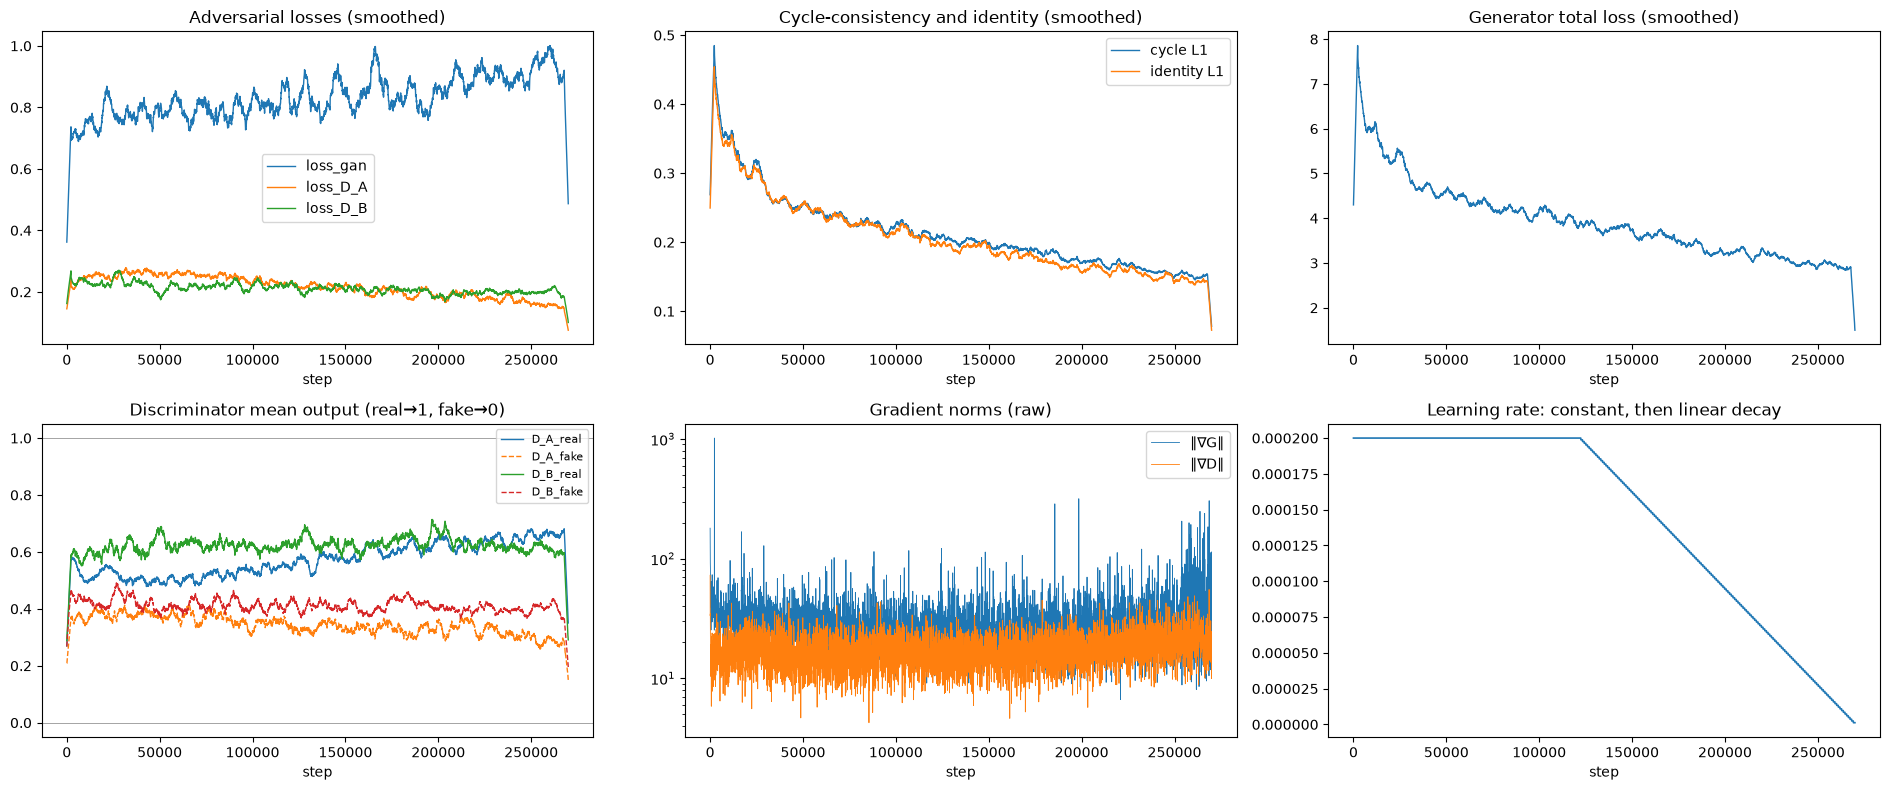

,epoch,lr,lambda_id_BA,lambda_id_AB,loss_G,loss_gan,loss_cyc,loss_id,loss_D_A,loss_D_B,D_A_real,D_A_fake,D_B_real,D_B_fake,gnorm_G,gnorm_D,wall_time_min,peak_mem_mb
0,1,0.0002,5.0000,5.0,9.3006,0.7164,0.5866,0.5437,0.3219,0.3242,0.5278,0.4699,0.5196,0.4810,67.4873,15.2554,1.8363,3386.0684
1,2,0.0002,5.0000,5.0,7.9814,0.6667,0.5034,0.4561,0.2388,0.2512,0.5663,0.4352,0.5299,0.4688,50.8956,14.2250,3.6053,3386.0684
2,3,0.0002,5.0000,5.0,7.4687,0.7588,0.4600,0.4220,0.2115,0.2396,0.6129,0.3881,0.5511,0.4504,46.8315,16.2004,5.3867,3386.0684
3,4,0.0002,5.0000,5.0,7.1010,0.8106,0.4279,0.4023,0.1946,0.2284,0.6408,0.3624,0.5752,0.4245,41.2842,18.6460,7.2462,3386.0684
4,5,0.0002,5.0000,5.0,6.9677,0.8129,0.4189,0.3932,0.2068,0.2131,0.6195,0.3825,0.6016,0.3957,41.0841,18.8973,9.0865,3386.0684
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,296,0.0000,1.6061,5.0,2.8936,0.9764,0.1456,0.1390,0.1366,0.1840,0.7112,0.2888,0.6248,0.3747,40.8067,21.0357,526.3505,3386.0684
296,297,0.0000,1.5848,5.0,2.8960,0.9756,0.1455,0.1401,0.1373,0.1826,0.7119,0.2895,0.6240,0.3739,41.2680,20.9980,528.0752,3386.0684
297,298,0.0000,1.5636,5.0,2.8978,0.9886,0.1448,0.1396,0.1390,0.1803,0.7073,0.2930,0.6290,0.3741,43.4357,21.0383,529.8003,3386.0684
298,299,0.0000,1.5424,5.0,2.9003,0.9806,0.1458,0.1401,0.1359,0.1808,0.7112,0.2895,0.6263,0.3697,44.7799,20.9130,531.5268,3386.0684


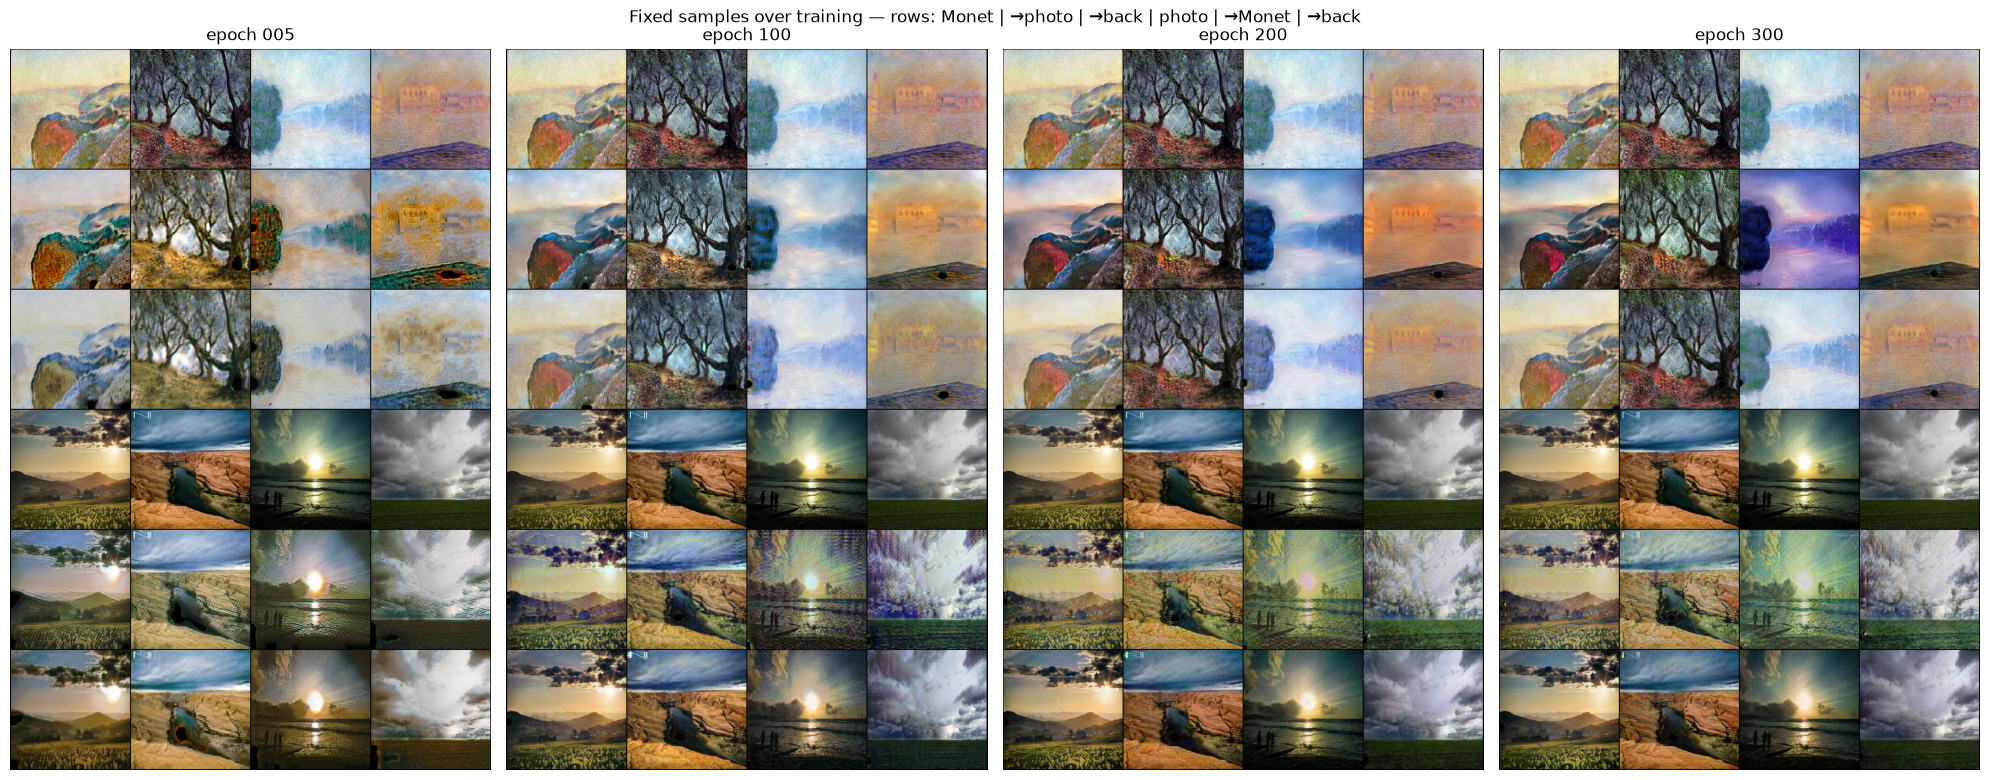

In [12]:
import pandas as pd
rows = [r for r in read_run_logs(train_result) if "loss_G" in r and "event" not in r]
print(f"Raw logs ({len(train_result['log_paths'])} session(s)):", *[Path(p).name for p in train_result["log_paths"]], sep="\n  ")
s = np.array([r["step"] for r in rows])
def sm(key, w=max(1, len(rows) // 60)):                     # moving average for readability (raw values stay in the log)
    v = np.array([r[key] for r in rows], dtype=float)
    return np.convolve(v, np.ones(w) / w, mode="same") if len(v) > w else v
fig, ax = plt.subplots(2, 3, figsize=(19, 8))
for k in ("loss_gan", "loss_D_A", "loss_D_B"):
    ax[0, 0].plot(s, sm(k), lw=1, label=k)
ax[0, 0].set_title("Adversarial losses (smoothed)"); ax[0, 0].legend()
ax[0, 1].plot(s, sm("loss_cyc"), lw=1, label="cycle L1"); ax[0, 1].plot(s, sm("loss_id"), lw=1, label="identity L1")
ax[0, 1].set_title("Cycle-consistency and identity (smoothed)"); ax[0, 1].legend()
ax[0, 2].plot(s, sm("loss_G"), lw=1); ax[0, 2].set_title("Generator total loss (smoothed)")
for k, ls in (("D_A_real", "-"), ("D_A_fake", "--"), ("D_B_real", "-"), ("D_B_fake", "--")):
    ax[1, 0].plot(s, sm(k), ls, lw=1, label=k)
ax[1, 0].axhline(1, c="grey", lw=0.5); ax[1, 0].axhline(0, c="grey", lw=0.5)
ax[1, 0].set_title("Discriminator mean output (real→1, fake→0)"); ax[1, 0].legend(fontsize=8)
ax[1, 1].plot(s, [r["gnorm_G"] for r in rows], lw=0.6, label="‖∇G‖"); ax[1, 1].plot(s, [r["gnorm_D"] for r in rows], lw=0.6, label="‖∇D‖")
ax[1, 1].set_yscale("log"); ax[1, 1].set_title("Gradient norms (raw)"); ax[1, 1].legend()
ax[1, 2].plot(s, [r["lr"] for r in rows], lw=1.2); ax[1, 2].set_title("Learning rate: constant, then linear decay")
for a in ax.flat: a.set_xlabel("step")
plt.tight_layout(); plt.savefig(OUT_DIR / "loss_curves.png", dpi=150); plt.show()

EPOCH_TBL = pd.DataFrame(train_result["history"]); EPOCH_TBL["epoch"] += 1
cols = ["epoch", "lr", "lambda_id_BA", "lambda_id_AB", "loss_G", "loss_gan", "loss_cyc", "loss_id", "loss_D_A", "loss_D_B",
        "D_A_real", "D_A_fake", "D_B_real", "D_B_fake", "gnorm_G", "gnorm_D", "wall_time_min", "peak_mem_mb"]
EPOCH_TBL = EPOCH_TBL[[c for c in cols if c in EPOCH_TBL]]
EPOCH_TBL.to_csv(OUT_DIR / "epoch_history.csv", index=False)
display(EPOCH_TBL.round(4))

# Visual progress across training (fixed samples): rows = real A | fake B | rec A | real B | fake A | rec B
grids = sorted(SAMPLE_DIR.glob("epoch_*.png"))
pick = [grids[k] for k in sorted(set(np.linspace(0, len(grids) - 1, min(4, len(grids))).astype(int)))] if grids else []
if pick:
    fig, ax = plt.subplots(1, len(pick), figsize=(5 * len(pick), 8))
    for a, g in zip(np.atleast_1d(ax), pick):
        a.imshow(Image.open(g)); a.set_title(g.stem.replace("_", " ")); a.axis("off")
    plt.suptitle("Fixed samples over training — rows: Monet | →photo | →back | photo | →Monet | →back"); plt.tight_layout(); plt.show()

### Interpretation — training behaviour (fill in after the run)
- **Convergence:** cycle L1 fell from [x] (epoch 1) to [x] (final); identity L1 [x] → [x]. G adversarial loss settles around [x]; in a healthy GAN it does *not* go to 0.
- **Balance:** D outputs on real stay near [x] and on fakes near [x]. If D_fake → 0 and D_real → 1 for long stretches, D is winning (G gradients vanish); if both hover near 0.5, neither is learning much.
- **Stability:** [n] NaNs; gradient norms [stable / spikes at steps …]. After epoch [decay_start], the LR decay shows as smaller oscillations.
- **Visual progress:** early epochs mostly change colour; by epoch [x] brush-stroke texture appears; [any artefacts: checkerboard, colour blotches, mode collapse].

## 4. Translation in both directions (3.1.4)
Output filenames match the input filenames, so every output traces back to its source.

pred_A2B: 300 imgs (291.8 img/s)   pred_B2A: 300 imgs (358.2 img/s)


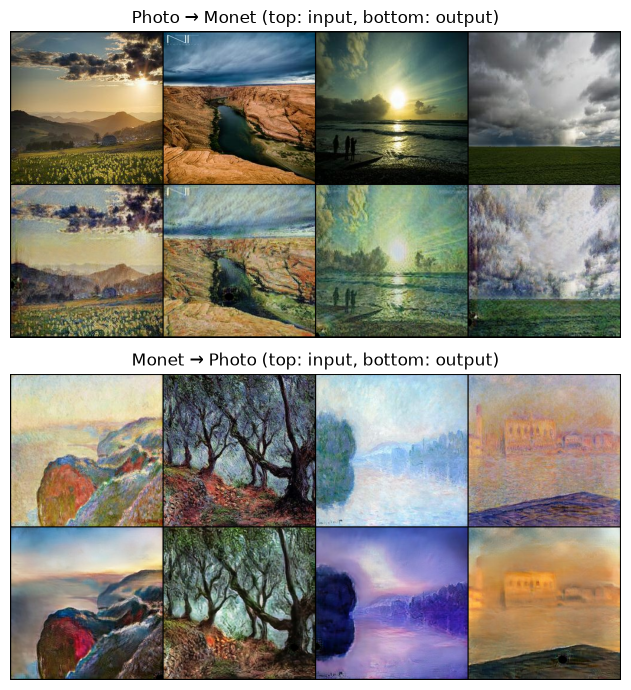

In [13]:
@torch.no_grad()
def translate_folder(G, in_paths, out_dir, batch_size=8):
    G.eval(); n, t_total = 0, 0.0
    for f in Path(out_dir).glob("*"):
        f.unlink()
    for i in range(0, len(in_paths), batch_size):
        chunk = in_paths[i:i + batch_size]
        x = torch.stack([EVAL_TF(Image.open(p).convert("RGB")) for p in chunk]).to(DEVICE)
        t0 = time.time(); y = G(x); _sync(); t_total += time.time() - t0
        for p, img in zip(chunk, denorm(y).cpu()):
            T.functional.to_pil_image(img).save(Path(out_dir) / (Path(p).stem + ".jpg"), quality=95)
        n += len(chunk)
    G.train()
    return n / t_total

G_AB.load_state_dict(load_checkpoint(CKPT_DIR / "G_AB.pt", DEVICE)["model"])   # final-epoch generators
G_BA.load_state_dict(load_checkpoint(CKPT_DIR / "G_BA.pt", DEVICE)["model"])
photo_in = B_PATHS if CFG["translate_all_photos"] else B_PATHS[:CFG["n_eval"]]
IPS_A2B = translate_folder(G_AB, A_PATHS[:CFG["n_eval"]], PRED_A2B)   # Monet -> Photo
IPS_B2A = translate_folder(G_BA, photo_in, PRED_B2A)                  # Photo -> Monet
print(f"pred_A2B: {len(list(PRED_A2B.glob('*.jpg')))} imgs ({IPS_A2B:.1f} img/s)   pred_B2A: {len(list(PRED_B2A.glob('*.jpg')))} imgs ({IPS_B2A:.1f} img/s)")
grid = [EVAL_TF(Image.open(p).convert("RGB")) for p in B_PATHS[:4]] + [EVAL_TF(Image.open(PRED_B2A / (Path(p).stem + ".jpg")).convert("RGB")) for p in B_PATHS[:4]]
save_image(make_grid(denorm(torch.stack(grid)), nrow=4), OUT_DIR / "examples_photo2monet.png")
grid = [EVAL_TF(Image.open(p).convert("RGB")) for p in A_PATHS[:4]] + [EVAL_TF(Image.open(PRED_A2B / (Path(p).stem + ".jpg")).convert("RGB")) for p in A_PATHS[:4]]
save_image(make_grid(denorm(torch.stack(grid)), nrow=4), OUT_DIR / "examples_monet2photo.png")
fig, ax = plt.subplots(2, 1, figsize=(12, 7))
for a, f, t in ((ax[0], "examples_photo2monet.png", "Photo → Monet (top: input, bottom: output)"),
                (ax[1], "examples_monet2photo.png", "Monet → Photo (top: input, bottom: output)")):
    a.imshow(Image.open(OUT_DIR / f)); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

epoch  10: FID  148.12 (A2B  147.8, B2A  148.5) | kaggle ≈ -74.272


epoch  20: FID  138.06 (A2B  136.1, B2A  140.0) | kaggle ≈ -69.241


epoch  30: FID  124.48 (A2B  126.2, B2A  122.8) | kaggle ≈ -62.451


epoch  40: FID  122.19 (A2B  125.0, B2A  119.4) | kaggle ≈ -61.303


epoch  50: FID  120.07 (A2B  122.6, B2A  117.6) | kaggle ≈ -60.244


...

epoch 260: FID  100.04 (A2B  102.1, B2A   98.0) | kaggle ≈ -50.228


epoch 270: FID   99.04 (A2B  101.2, B2A   96.9) | kaggle ≈ -49.724


epoch 280: FID   98.70 (A2B  100.9, B2A   96.5) | kaggle ≈ -49.557


epoch 290: FID   99.24 (A2B  101.4, B2A   97.1) | kaggle ≈ -49.827


epoch 300: FID   98.96 (A2B  101.1, B2A   96.9) | kaggle ≈ -49.684


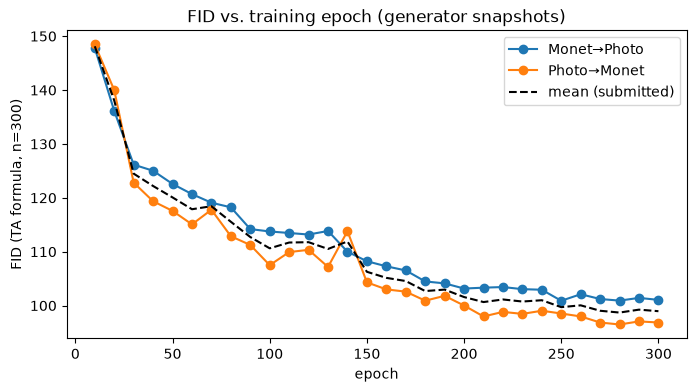


Selected epoch 280: FID 98.70, Kaggle ≈ -49.557


Re-translated pred_A2B / pred_B2A with epoch-280 generators -> sections 5-9 use these.


In [14]:
# ── Checkpoint selection: score every generator snapshot with the Kaggle formula, use the best ──
import shutil, tempfile
SNAP_DIR = CKPT_DIR / "snapshots"
snaps = sorted(SNAP_DIR.glob("G_AB_e*.pt")) if SNAP_DIR.exists() else []
SELECTED_EPOCH = None
if snaps:
    n = CFG["n_eval"]
    F_monet = EL.inception_features(EL.list_images(MONET_DIR)[:n], DEVICE)
    F_photo = EL.inception_features(EL.list_images(PHOTO_DIR)[:n], DEVICE)
    tmp = Path(tempfile.gettempdir()) / "snap_eval"
    (tmp / "A2B").mkdir(parents=True, exist_ok=True); (tmp / "B2A").mkdir(parents=True, exist_ok=True)
    sel = []
    for p_ab in snaps:
        ep = int(p_ab.stem.split("_e")[1]); p_ba = SNAP_DIR / f"G_BA_e{ep:03d}.pt"
        G_AB.load_state_dict(load_checkpoint(p_ab, DEVICE)["model"]); G_BA.load_state_dict(load_checkpoint(p_ba, DEVICE)["model"])
        translate_folder(G_AB, A_PATHS[:n], tmp / "A2B"); translate_folder(G_BA, B_PATHS[:n], tmp / "B2A")
        fa, ma = EL.ta_fid_mifid(F_photo, EL.inception_features(EL.list_images(tmp / "A2B")[:n], DEVICE))
        fb, mb = EL.ta_fid_mifid(F_monet, EL.inception_features(EL.list_images(tmp / "B2A")[:n], DEVICE))
        fid, mifid = (fa + fb) / 2, (ma + mb) / 2
        sel.append({"epoch": ep, "FID_A2B": fa, "FID_B2A": fb, "FID": fid, "MiFID": mifid, "kaggle_score": -(fid + mifid) / 2})
        print(f"epoch {ep:3d}: FID {fid:7.2f} (A2B {fa:6.1f}, B2A {fb:6.1f}) | kaggle ≈ {-(fid + mifid) / 2:.3f}")
    shutil.rmtree(tmp, ignore_errors=True)
    SEL = pd.DataFrame(sel).sort_values("epoch"); SEL.to_csv(OUT_DIR / "checkpoint_selection.csv", index=False)
    plt.figure(figsize=(8, 4)); plt.plot(SEL.epoch, SEL.FID_A2B, "o-", label="Monet→Photo"); plt.plot(SEL.epoch, SEL.FID_B2A, "o-", label="Photo→Monet")
    plt.plot(SEL.epoch, SEL.FID, "k--", label="mean (submitted)"); plt.xlabel("epoch"); plt.ylabel("FID (TA formula, n=300)")
    plt.title("FID vs. training epoch (generator snapshots)"); plt.legend(); plt.savefig(OUT_DIR / "fid_vs_epoch.png", dpi=150); plt.show()
    best = SEL.loc[SEL.kaggle_score.idxmax()]; SELECTED_EPOCH = int(best.epoch)
    print(f"\nSelected epoch {SELECTED_EPOCH}: FID {best.FID:.2f}, Kaggle ≈ {best.kaggle_score:.3f}")
    shutil.copy2(SNAP_DIR / f"G_AB_e{SELECTED_EPOCH:03d}.pt", CKPT_DIR / "G_AB.pt")   # submitted generators = selected snapshot
    shutil.copy2(SNAP_DIR / f"G_BA_e{SELECTED_EPOCH:03d}.pt", CKPT_DIR / "G_BA.pt")
    G_AB.load_state_dict(load_checkpoint(CKPT_DIR / "G_AB.pt", DEVICE)["model"]); G_BA.load_state_dict(load_checkpoint(CKPT_DIR / "G_BA.pt", DEVICE)["model"])
    IPS_A2B = translate_folder(G_AB, A_PATHS[:CFG["n_eval"]], PRED_A2B)
    IPS_B2A = translate_folder(G_BA, photo_in, PRED_B2A)
    print(f"Re-translated pred_A2B / pred_B2A with epoch-{SELECTED_EPOCH} generators -> sections 5-9 use these.")
else:
    print("No snapshots found: using final-epoch generators.")

## 5. Cycle-consistency verification (3.2.2)
If the cycle constraint is implemented correctly, `G_BA(G_AB(a)) ≈ a` and `G_AB(G_BA(b)) ≈ b`. This reports the mean L1 (in [-1, 1] pixel space) over held-out inputs and saves visual triplets.

cycle L1  A→B→A: 0.0785   B→A→B: 0.0849


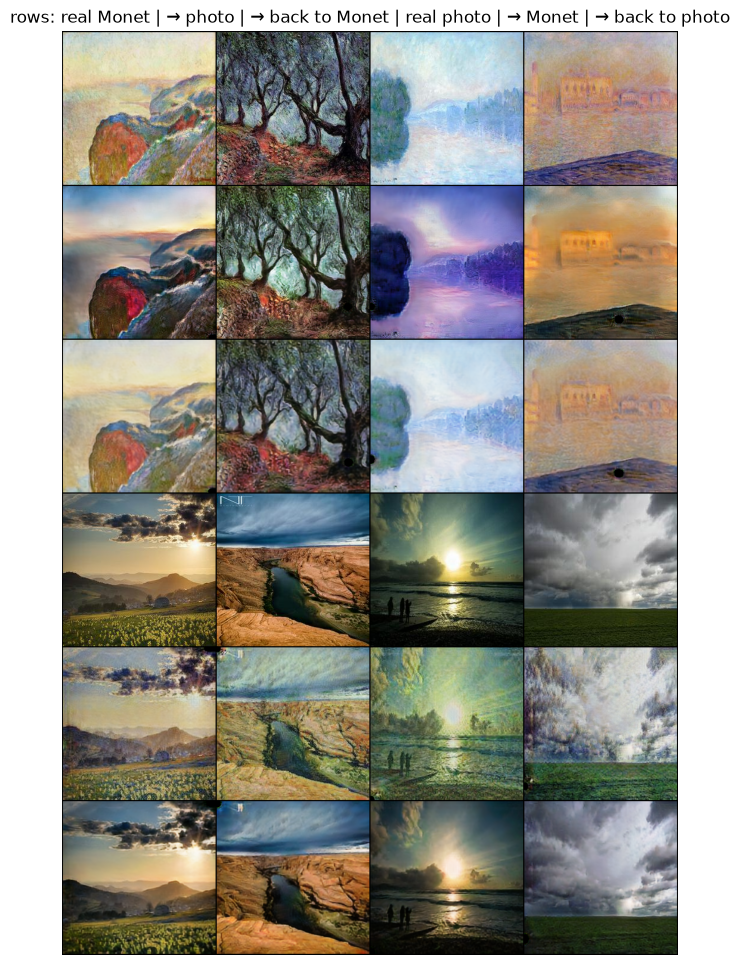

In [15]:
@torch.no_grad()
def cycle_l1(G1, G2, paths, batch_size=8):
    G1.eval(); G2.eval(); vals = []
    for i in range(0, len(paths), batch_size):
        x = torch.stack([EVAL_TF(Image.open(p).convert("RGB")) for p in paths[i:i + batch_size]]).to(DEVICE)
        vals.append((G2(G1(x)) - x).abs().mean(dim=(1, 2, 3)).cpu())
    G1.train(); G2.train()
    return float(torch.cat(vals).mean())

CYC_A = cycle_l1(G_AB, G_BA, A_PATHS[:CFG["n_eval"]])   # Monet -> Photo -> Monet
CYC_B = cycle_l1(G_BA, G_AB, B_PATHS[:CFG["n_eval"]])   # Photo -> Monet -> Photo
save_progress_grid(OUT_DIR / "cycle_verification.png")
print(f"cycle L1  A→B→A: {CYC_A:.4f}   B→A→B: {CYC_B:.4f}")
plt.figure(figsize=(10, 12)); plt.imshow(Image.open(OUT_DIR / "cycle_verification.png")); plt.axis("off")
plt.title("rows: real Monet | → photo | → back to Monet | real photo | → Monet | → back to photo"); plt.show()

## 6. Kaggle submission and full metrics (3.2)
`evaluate_local.py` reproduces the TA script's FID/MiFID exactly (same Inception model, preprocessing, first-300 sorted files, and averaging) and writes `submission.csv` to the member folder. It also computes KID, precision/recall/density/coverage, LPIPS, and content cosine. You can still run the TA notebook as a cross-check; the folders below are already in the layout it expects.

In [16]:
FM = EL.evaluate(DATA_DIR, OUT_DIR, MEMBER_DIR, n_eval=CFG["n_eval"], device=DEVICE)
print(open(MEMBER_DIR / "submission.csv").read())
# Cross-check with the TA notebook: point its BASE at this folder (symlinks, no copying)
TA_BASE = OUT_DIR / "ta_eval"; TA_BASE.mkdir(exist_ok=True)
try:
    for name, target in {"monet_jpg": MONET_DIR, "photo_jpg": PHOTO_DIR, "pred_A2B": PRED_A2B, "pred_B2A": PRED_B2A}.items():
        link = TA_BASE / name
        if link.is_symlink() or link.exists(): link.unlink()
        link.symlink_to(Path(target).resolve(), target_is_directory=True)
    print("TA script BASE =", TA_BASE)
except OSError as e:   # Windows needs admin / Developer Mode for symlinks — the cross-check is optional
    print(f"Skipped TA-script folder links ({type(e).__name__}). submission.csv above is already TA-identical; "
          f"to cross-check, set BASE in the TA notebook to a folder containing monet_jpg, photo_jpg, and copies of outputs/pred_A2B, pred_B2A.")
import pandas as pd
pd.Series(FM).to_frame("value")

<REPO>\.venv\Lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
<REPO>\.venv\Lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ID,FID,MiFID
1,98.70296481457521,0.41055701854240834

Skipped TA-script folder links (OSError). submission.csv above is already TA-identical; to cross-check, set BASE in the TA notebook to a folder containing monet_jpg, photo_jpg, and copies of outputs/pred_A2B, pred_B2A.


,value
n_eval,300.000000
FID_A2B,100.919061
FID_B2A,96.486868
MiFID_A2B,0.416624
MiFID_B2A,0.404490
submission_FID,98.702965
submission_MiFID,0.410557
KID_A2B_mean,0.018077
KID_A2B_std,0.002246
precision_A2B,0.746667


## 7. Blinded human audit (3.2.6)
This exports 30 fixed samples (15 per direction, chosen with seed 1446) as side-by-side `input | output` images under shuffled anonymous IDs, plus one rating sheet per rater. **Raters see only the IDs.** `audit_key.csv` maps IDs back to directions and files, so don't share it with the raters.

Rating scale: `style` 1–5 (how convincingly it's in the target domain), `content` 1–5 (scene preserved), `artifacts` 0/1.

In [17]:
AUDIT_DIR = OUT_DIR / "audit"; AUDIT_DIR.mkdir(exist_ok=True)

def export_audit_sheet(n):
    rng = np.random.default_rng(SEED)
    half = n // 2
    a_pick = rng.choice(min(len(A_PATHS), CFG["n_eval"]), half, replace=False)
    b_pick = rng.choice(min(len(B_PATHS), CFG["n_eval"]), n - half, replace=False)
    items = [("Monet→Photo", A_PATHS[i], PRED_A2B) for i in a_pick] + [("Photo→Monet", B_PATHS[i], PRED_B2A) for i in b_pick]
    order = rng.permutation(len(items)); key = []
    for new_id, j in enumerate(order, 1):
        direction, src, pred_dir = items[j]
        x = EVAL_TF(Image.open(src).convert("RGB")); y = EVAL_TF(Image.open(pred_dir / (Path(src).stem + ".jpg")).convert("RGB"))
        sid = f"S{new_id:02d}"
        save_image(make_grid(denorm(torch.stack([x, y])), nrow=2, padding=4, pad_value=1), AUDIT_DIR / f"{sid}.png")
        key.append({"sample_id": sid, "direction": direction, "source_file": Path(src).name})
    pd.DataFrame(key).to_csv(OUT_DIR / "audit_key.csv", index=False)
    sheet = pd.DataFrame({"sample_id": [k["sample_id"] for k in key], "style_1to5": "", "content_1to5": "", "artifacts_0or1": ""})
    for r in (1, 2):
        p = OUT_DIR / f"audit_rater{r}.csv"
        if not p.exists():                                    # never overwrite completed ratings
            sheet.to_csv(p, index=False)
    print(f"{len(key)} audit images -> {AUDIT_DIR}; sheets audit_rater1.csv / audit_rater2.csv")

def audit_agreement(r1_csv, r2_csv):
    from sklearn.metrics import cohen_kappa_score
    a, b = pd.read_csv(r1_csv), pd.read_csv(r2_csv)
    m = a.merge(b, on="sample_id", suffixes=("_r1", "_r2")).dropna()
    if m.empty:
        return {}
    out = {"audit_n": len(m)}
    for col, w in (("style_1to5", "quadratic"), ("content_1to5", "quadratic"), ("artifacts_0or1", None)):
        x, y = m[f"{col}_r1"].astype(int), m[f"{col}_r2"].astype(int)
        out[f"kappa_{col}"] = cohen_kappa_score(x, y, weights=w)
        out[f"pct_agree_{col}"] = float((x == y).mean())
        out[f"mean_{col}"] = float((x + y).mean() / 2)
    return out

export_audit_sheet(CFG["n_audit"])
AUDIT = {}
try:
    AUDIT = audit_agreement(OUT_DIR / "audit_rater1.csv", OUT_DIR / "audit_rater2.csv")
except Exception as e:
    print("Audit not rated yet — fill both sheets, then rerun this cell and the next one.", type(e).__name__)
AUDIT

30 audit images -> <REPO>\task3_gan\tejas\outputs\audit; sheets audit_rater1.csv / audit_rater2.csv


{}

## 8. All metrics → `full_metrics_report.csv` / `metrics_report.csv`
After submitting `submission.csv` to Kaggle, set the three `KAGGLE_*` values and rerun this cell.

In [18]:
KAGGLE_PUBLIC, KAGGLE_PRIVATE, KAGGLE_RANK = None, None, None   # fill in after submitting
hw = hardware_info(DEVICE)
full = {"member": MEMBER, "run_name": CFG["run_name"], "seed": SEED,
        "arch": f"ResNet-{CFG['n_res_blocks']} G (ngf {CFG['ngf']}) + 70x70 PatchGAN D (ndf {CFG['ndf']}), LSGAN, "
                f"λcyc={CFG['lambda_cycle']}, λid={CFG['lambda_id']}, {CFG['epochs']} epochs × {CFG['iters_per_epoch']} it",
        **FM, "cycle_L1_A2B2A": CYC_A, "cycle_L1_B2A2B": CYC_B,
        "final_cycle_loss": train_result["final_loss_cyc"], "final_identity_loss": train_result["final_loss_id"],
        "final_loss_G": train_result["final_loss_G"], "final_loss_D_A": train_result["final_loss_D_A"], "final_loss_D_B": train_result["final_loss_D_B"],
        "nan_count": train_result["nan_count"],
        "max_gnorm_G": max(r["gnorm_G"] for r in rows), "max_gnorm_D": max(r["gnorm_D"] for r in rows),
        "mean_gnorm_G": float(np.mean([r["gnorm_G"] for r in rows])), "mean_gnorm_D": float(np.mean([r["gnorm_D"] for r in rows])),
        **AUDIT,
        "params_total": sum(PARAMS.values()), **{f"params_{k}": v for k, v in PARAMS.items()},
        "train_time_min": train_result["total_time_s"] / 60, "wall_time_min": train_result["wall_time_s"] / 60,
        "train_img_per_sec": train_result["mean_img_per_sec"],
        "infer_img_per_sec_A2B": IPS_A2B, "infer_img_per_sec_B2A": IPS_B2A, "peak_memory_mb": train_result["peak_mem_mb"],
        "gpu": hw.get("gpu", "none"), "cpu": f'{hw["cpu"]} ({hw["cpu_count"]} cores)',
        "kaggle_public": KAGGLE_PUBLIC, "kaggle_private": KAGGLE_PRIVATE, "kaggle_rank": KAGGLE_RANK,
        "checkpoint": "checkpoints/G_AB.pt + G_BA.pt", "raw_log": "; ".join(Path(p).name for p in train_result["log_paths"])}
write_metrics_csv([full], MEMBER_DIR / "full_metrics_report.csv")
write_metrics_csv([full], MEMBER_DIR / "metrics_report.csv")
write_manifest(CFG, DEVICE, {"checkpoint_to_result": {"checkpoints/G_AB.pt": "outputs/pred_A2B (Monet→Photo)",
                                                       "checkpoints/G_BA.pt": "outputs/pred_B2A (Photo→Monet)",
                                                       "checkpoints/G_AB.pt + G_BA.pt": "submission.csv, full_metrics_report.csv",
                                                       "checkpoints/last.pt": "resume point (all 4 nets + optimizers)"},
                             "params": PARAMS, "raw_logs": train_result["log_paths"]})
groups = {
    "Kaggle file (TA-identical)": ["submission_FID", "submission_MiFID", "FID_A2B", "FID_B2A", "MiFID_A2B", "MiFID_B2A", "n_eval"],
    "Distribution metrics": ["KID_A2B_mean", "KID_A2B_std", "KID_B2A_mean", "KID_B2A_std",
                             "precision_A2B", "recall_A2B", "density_A2B", "coverage_A2B",
                             "precision_B2A", "recall_B2A", "density_B2A", "coverage_B2A"],
    "Content preservation": ["cycle_L1_A2B2A", "cycle_L1_B2A2B", "LPIPS_A2B", "LPIPS_B2A", "content_cosine_A2B", "content_cosine_B2A"],
    "Losses (final epoch)": ["final_cycle_loss", "final_identity_loss", "final_loss_G", "final_loss_D_A", "final_loss_D_B"],
    "Training stability": ["nan_count", "max_gnorm_G", "max_gnorm_D", "mean_gnorm_G", "mean_gnorm_D"],
    "Human audit": [k for k in full if k.startswith(("audit_", "kappa_", "pct_agree_", "mean_style", "mean_content", "mean_artifacts"))],
    "Cost / efficiency": ["params_total", "params_G_AB", "params_G_BA", "params_D_A", "params_D_B", "train_time_min", "wall_time_min",
                          "train_img_per_sec", "infer_img_per_sec_A2B", "infer_img_per_sec_B2A", "peak_memory_mb"],
    "Hardware / leaderboard / provenance": ["gpu", "cpu", "kaggle_public", "kaggle_private", "kaggle_rank", "arch", "checkpoint", "raw_log"],
}
for g, keys in groups.items():
    print(f"\n── {g} ──")
    if keys:
        display(pd.Series({k: full.get(k) for k in keys}, name="value").to_frame())
    else:
        print("   (not rated yet: fill audit_rater1.csv / audit_rater2.csv, rerun section 7 and this cell)")

Metrics -> <REPO>\task3_gan\tejas\full_metrics_report.csv
Metrics -> <REPO>\task3_gan\tejas\metrics_report.csv


Manifest -> <REPO>\reproducibility\manifests\task3_gan\tejas\manifest_t3_cyclegan_tejas.json

── Kaggle file (TA-identical) ──


,value
submission_FID,98.702965
submission_MiFID,0.410557
FID_A2B,100.919061
FID_B2A,96.486868
MiFID_A2B,0.416624
MiFID_B2A,0.404490
n_eval,300.000000



── Distribution metrics ──


,value
KID_A2B_mean,0.018077
KID_A2B_std,0.002246
KID_B2A_mean,0.006593
KID_B2A_std,0.001495
precision_A2B,0.746667
recall_A2B,0.483333
density_A2B,1.078000
coverage_A2B,0.906667
precision_B2A,0.543333
recall_B2A,0.720000


...

,value
nan_count,0.000000
max_gnorm_G,1017.873373
max_gnorm_D,72.526571
mean_gnorm_G,29.463410
mean_gnorm_D,17.460212



── Human audit ──
   (not rated yet: fill audit_rater1.csv / audit_rater2.csv, rerun section 7 and this cell)

── Cost / efficiency ──


,value
params_total,2.828583e+07
params_G_AB,1.137818e+07
params_G_BA,1.137818e+07
params_D_A,2.764737e+06
params_D_B,2.764737e+06
train_time_min,5.069781e+02
wall_time_min,5.332490e+02
train_img_per_sec,1.778156e+01
infer_img_per_sec_A2B,2.708603e+02
infer_img_per_sec_B2A,3.607820e+02



── Hardware / leaderboard / provenance ──


,value
gpu,NVIDIA GeForce RTX 4090
cpu,AMD Ryzen 9 7950X 16-Core Processor (32 cores)
kaggle_public,NaN
kaggle_private,NaN
kaggle_rank,NaN
arch,ResNet-9 G (ngf 64) + 70x70 PatchGAN D (ndf 64...
checkpoint,checkpoints/G_AB.pt + G_BA.pt
raw_log,t3_cyclegan_tejas_20261002-132424.jsonl


### Interpretation — metrics (fill in after the run)
- **Kaggle score:** submission FID [x] / MiFID [x]; Photo→Monet FID [x] vs. Monet→Photo [x]. [Which direction is easier and why; only 300 Monets to learn the style from.]
- **KID** [x ± y] agrees with FID's ranking of the two directions; KID is unbiased at small sample sizes, which matters with n = 300.
- **Precision vs. recall:** precision [x] (outputs look like real samples) vs. recall [x] (outputs cover the variety of the real set); low recall suggests [mode collapse / limited style variety].
- **Content preservation:** cycle L1 [x] and content cosine [x] show the scene survives translation; LPIPS [x] measures how much the image *changed* perceptually. It should be clearly > 0 (style applied) but not huge (content kept).
- **Human audit:** mean style [x]/5, content [x]/5, artifacts in [x]% of samples; agreement κ = [x] ([slight / fair / moderate / substantial]).

## 9. Export zip + save everything to Google Drive
The zip is laid out like the repo, so unzip it at the **repo root**. It holds the weights-only generators, not `last.pt` (~340 MB, too big for GitHub; it stays on Drive). On Colab the files are already on Drive, and the last cell verifies them, makes a timestamped backup, and flushes Drive.

In [19]:
# ── Final: verify artifacts, make a timestamped backup, and force Drive to finish syncing (Colab) ──
import shutil, time
must_exist = [MEMBER_DIR / "metrics_report.csv", MEMBER_DIR / "full_metrics_report.csv", MEMBER_DIR / "submission.csv",
              MEMBER_DIR / "evaluate_local.py", CKPT_DIR / "G_AB.pt", CKPT_DIR / "G_BA.pt", CKPT_DIR / "last.pt",
              OUT_DIR / "loss_curves.png", OUT_DIR / "epoch_history.csv", OUT_DIR / "cycle_verification.png",
              OUT_DIR / "audit_key.csv", OUT_DIR / "audit_rater1.csv", OUT_DIR / "audit_rater2.csv",
              MANI_DIR / f"manifest_{CFG['run_name']}.json"]
for p in must_exist:
    print("✅" if p.exists() else "❌", p.relative_to(REPO_ROOT))
for d in (PRED_A2B, PRED_B2A):
    n = len(list(d.glob("*.jpg"))); print("✅" if n else "❌", d.relative_to(REPO_ROOT), f"({n} images)")
for p in train_result["log_paths"]:
    print("✅" if Path(p).exists() else "❌", Path(p).relative_to(REPO_ROOT))

if str(MEMBER_DIR).startswith("/content/drive"):
    BACKUP = REPO_ROOT.parent / "DATA266_backups" / f"task3_{MEMBER}_{time.strftime('%Y%m%d-%H%M%S')}"
    for src in (OUT_DIR, LOG_DIR, MANI_DIR):
        shutil.copytree(src, BACKUP / Path(src).relative_to(REPO_ROOT), dirs_exist_ok=True, ignore=shutil.ignore_patterns("ta_eval"))
    (BACKUP / "checkpoints").mkdir(parents=True, exist_ok=True)
    for f in ("G_AB.pt", "G_BA.pt"):
        shutil.copy2(CKPT_DIR / f, BACKUP / "checkpoints" / f)
    for f in ("metrics_report.csv", "full_metrics_report.csv", "submission.csv"):
        shutil.copy2(MEMBER_DIR / f, BACKUP / f)
    print(f"\nBackup -> {BACKUP}  ({sum(f.stat().st_size for f in BACKUP.rglob('*') if f.is_file())/1e6:.1f} MB)")
    from google.colab import drive
    drive.flush_and_unmount()
    print("Drive flushed and unmounted. Everything is safely on Drive. (Re-mount to keep working.)")
else:
    print(f"\nNot running from Google Drive (MEMBER_DIR={MEMBER_DIR}).")
    print("On the HPC/lab machine: copy the export zip (or the whole repo folder) off the machine before your session ends.")

✅ task3_gan\tejas\metrics_report.csv
✅ task3_gan\tejas\full_metrics_report.csv
✅ task3_gan\tejas\submission.csv
✅ task3_gan\tejas\evaluate_local.py
✅ task3_gan\tejas\checkpoints\G_AB.pt
✅ task3_gan\tejas\checkpoints\G_BA.pt
✅ task3_gan\tejas\checkpoints\last.pt
✅ task3_gan\tejas\outputs\loss_curves.png
✅ task3_gan\tejas\outputs\epoch_history.csv
✅ task3_gan\tejas\outputs\cycle_verification.png
✅ task3_gan\tejas\outputs\audit_key.csv
✅ task3_gan\tejas\outputs\audit_rater1.csv
✅ task3_gan\tejas\outputs\audit_rater2.csv
✅ reproducibility\manifests\task3_gan\tejas\manifest_t3_cyclegan_tejas.json
✅ task3_gan\tejas\outputs\pred_A2B (300 images)
✅ task3_gan\tejas\outputs\pred_B2A (300 images)
✅ reproducibility\raw_logs\task3_gan\tejas\t3_cyclegan_tejas_20261002-132424.jsonl

Not running from Google Drive (MEMBER_DIR=<REPO>\task3_gan\tejas).
On the HPC/lab machine: copy the export zip (or the whole repo folder) off the machine before your session ends.


**Your writing:** the visual quality assessment, cycle-consistency verification (cite `cycle_verification.png`), training-stability analysis (curves and the D-output panel), and shortcomings go in `results.md`. Record your Kaggle rank there too. Both teammates must each submit to Kaggle.